# Pair-production transport operator

Given a 3D activity distribution and a CT, this returns the 3D
distribution of pair-production vertices: the places where the
high-energy photons actually convert, which is what a PET scanner
records.

For $^{212}$Pb the imaged photon is the 2.6145 MeV emission of
$^{208}$Tl, two decays downstream. It travels a mean free path of
about 24 cm in soft tissue before interacting, so conversions are
displaced from the decays by a distance comparable to the patient.
The operator is

$$\Gamma f(\mathbf{r}) = b\,\mu_{\rm pp}(\mathbf{r})\int
\frac{e^{-\tau(\mathbf{r},\mathbf{r}')}}
{4\pi|\mathbf{r}-\mathbf{r}'|^{2}}\,f(\mathbf{r}')\,d^{3}r' ,$$

with $\tau$ the line integral of $\mu_{\rm tot}$ between the two
points, evaluated by Woodcock delta tracking in a CUDA kernel.

**A GPU is required.** There is no CPU path.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import hu_to_mu
from pp_vertex_mc import MCPPVertexTransform

assert torch.cuda.is_available(), 'this operator needs a GPU'
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 5090


## 1. A CT

Any HU array works here. This one is synthetic so the notebook needs
no data files, but it spans all five tissue classes. To use a real
study, replace this cell with a load and set `DR` to its voxel size:

```python
import SimpleITK as sitk
img = sitk.ReadImage('ct.nii.gz')
hu  = sitk.GetArrayFromImage(img)        # z, y, x
DR  = img.GetSpacing()[::-1]             # mm
```

Everything downstream is unchanged.

In [2]:
SHAPE = (64, 72, 72)          # z, y, x
DR = (5.0, 5.0, 5.0)          # mm

z, y, x = np.meshgrid(*[(np.arange(n) - (n - 1) / 2) * d
                        for n, d in zip(SHAPE, DR)], indexing='ij')

hu = np.full(SHAPE, -1000.0)                      # air
body = ((x / 150.0)**2 + (y / 100.0)**2 <= 1.0) & (np.abs(z) <= 140.0)
hu[body] = -70.0                                  # subcutaneous fat
inner = (x / 138.0)**2 + (y / 88.0)**2 <= 1.0
hu[inner & body] = 40.0                           # soft tissue
for sgn in (-1, 1):
    lung = ((x - sgn*62.0) / 46.0)**2 + (y / 62.0)**2 <= 1.0
    hu[lung & inner & (np.abs(z) <= 110.0)] = -700.0
spine = (x**2 + ((y - 66.0) / 1.3)**2 <= 24.0**2) & inner
hu[spine] = 1200.0                                # vertebral column

## 2. CT to attenuation and pair-production maps

`hu_to_mu` maps HU to mass density by the bilinear relation of
Schneider et al., assigns one of five tissue classes by threshold,
and subdivides each class into density bins. Water cross sections at
the line energy are scaled between classes by
$\langle Z/A\rangle$ for the total channel and
$\langle Z^2/A\rangle$ for the pair channel.

Those two scale differently, which is the whole point: the total
coefficient tracks electrons per gram, while pair production goes as
$Z^2$ per atom. $\Gamma$ therefore depends on anatomy rather than
acting as a blur.

In [3]:
bins = hu_to_mu.build_bins()
mu_tot, mu_pp = hu_to_mu.mu_maps(hu, 2.6145, bins)   # 1/mm

MU_PP_WATER = 8.346591e-5
print(f'{len(bins)} density bins')
for name, sel in [('lung', hu == -700), ('fat', hu == -70),
                  ('soft tissue', hu == 40), ('bone', hu == 1200)]:
    print(f'  {name:12s} mu_pp / water = {mu_pp[sel].mean() / MU_PP_WATER:5.2f}')

55 density bins
  lung         mu_pp / water =  0.31
  fat          mu_pp / water =  0.80
  soft tissue  mu_pp / water =  0.96
  bone         mu_pp / water =  2.44


## 3. An activity distribution

Uniform uptake through the soft tissue with four hotter lesions.

In [4]:
activity = np.zeros(SHAPE, np.float32)
activity[inner & body & (hu > -200)] = 1.0
for cx, cy, cz, rad in [(-40, -20, 20, 16.0), (55, 25, -30, 11.0),
                        (0, -55, -60, 8.0), (-80, 30, 55, 6.0)]:
    activity[(x-cx)**2 + (y-cy)**2 + (z-cz)**2 <= rad**2] = 8.0

## 4. Apply the operator

`n_photons` sets the variance and nothing else; the estimator is
unbiased at any count. What matters is $K$, the number of photon
groups launched per voxel, printed below.

In [5]:
op = MCPPVertexTransform(
    mu_tot, mu_pp,
    b=0.358,              # 2.6145 MeV gammas per 212Pb decay
    n_photons=int(6e8),
    ndir=8,
    seed=0,
)
op.setup(SHAPE, DR)
print(f'K = {op.K} groups per voxel')

f = torch.as_tensor(activity, device=op.device)
vertices = op.forward(f)

K = 226 groups per voxel


## 5. What the transport does

axial slice k=35, z=+18 mm


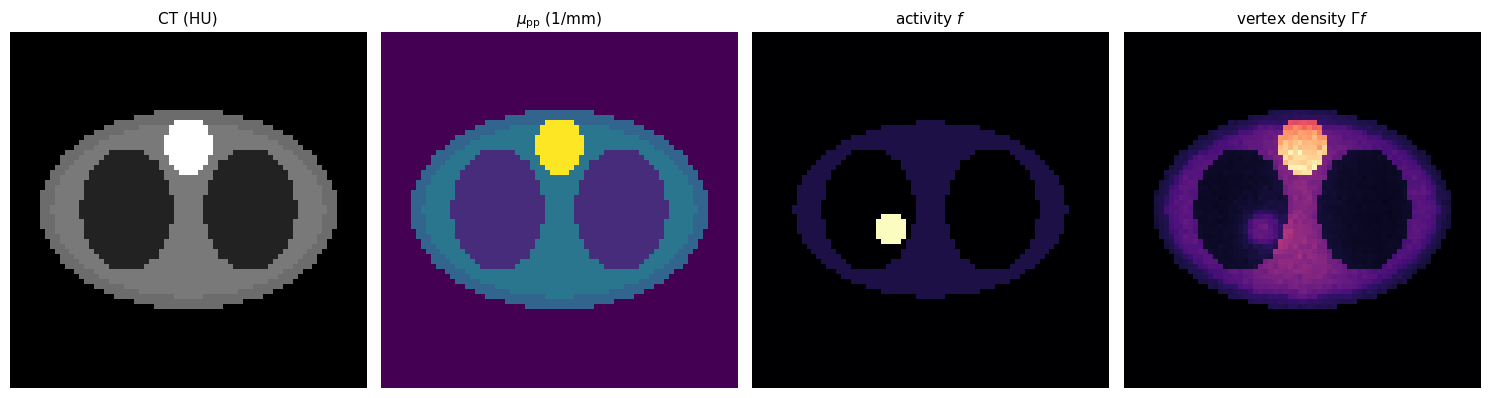

In [6]:
# Axial slice through the largest lesion. It also cuts lung, fat, soft
# tissue and the vertebral column, so every tissue class is present.
kz = int(np.argmax((activity > 4).sum(axis=(1, 2))))
print(f'axial slice k={kz}, z={(kz - (SHAPE[0]-1)/2) * DR[0]:+.0f} mm')

panels = [(hu[kz], 'CT (HU)', 'gray'),
          (mu_pp[kz], r'$\mu_{\rm pp}$ (1/mm)', 'viridis'),
          (activity[kz], 'activity $f$', 'magma'),
          (vertices.cpu().numpy()[kz],
           r'vertex density $\Gamma f$', 'magma')]

fig, ax = plt.subplots(1, 4, figsize=(15, 4.2))
for a, (img, ttl, cm) in zip(ax, panels):
    a.imshow(img, cmap=cm, origin='lower')
    a.set_title(ttl, fontsize=11)
    a.axis('off')
plt.tight_layout()
plt.show()

In [7]:
vn = vertices.cpu().numpy()
les = activity > 4.0
print(f'lesions hold {100*activity[les].sum()/activity.sum():.1f}% of the activity')
print(f'        but  {100*vn[les].sum()/vn.sum():.1f}% of the vertices')
print(f'vertex density, bone / lung = {vn[hu == 1200].mean() / vn[hu == -700].mean():.2f}')

lesions hold 3.0% of the activity
        but  0.2% of the vertices
vertex density, bone / lung = 9.21


Two things to read off the numbers.

The lesions are diluted by more than an order of magnitude, because
most conversions happen a mean free path away. Reconstructing this
vertex density without modelling $\Gamma$ converges to the vertex
density, not to the activity, which is what the operator is for.

The bone-to-lung ratio is far from unity even though the activity is
uniform across both. A shift-invariant kernel depends only on
$|\mathbf{r}-\mathbf{r}'|$ and is symmetric about its source, so it
cannot produce that asymmetry for any choice of width.

## 6. The adjoint

$\Gamma = b\,DK$ with $D$ diagonal in $\mu_{\rm pp}$ and $K$ a
symmetric kernel, so $\Gamma^{\rm T} = b\,KD \neq \Gamma$ unless
$\mu_{\rm pp}$ is constant. `backward()` is the exact transpose of
the matrix `forward()` realised, not a second estimate of the same
limit, because it gathers along the stored paths.

In [8]:
yv = torch.rand_like(f)
lhs = float((op.forward(f) * yv).sum())
rhs = float((f * op.backward(yv)).sum())
print(f'<Gf, y>    = {lhs:.8e}')
print(f'<f, G^T y> = {rhs:.8e}')
print(f'relative difference = {abs(lhs-rhs)/abs(lhs):.1e}')

<Gf, y>    = 5.87723770e+01
<f, G^T y> = 5.87725754e+01
relative difference = 3.4e-06


## 7. Using it in a reconstruction

`MCPPVertexTransform` subclasses `pytomography.transforms.Transform`
when PyTomography is installed and falls back to a standalone class
when it is not. Placed in the system matrix as
$H = N A P B\,\Gamma$, listmode OSEM converges to the activity
instead of to the vertex density.

See `CLAUDE.md` for the integration details and the invariants that
have to hold.